## Imports and utilitaries

Run all cells in this section before simulating.


In [1]:
# copied from all_possible_paths.py
 
### In this script I can try all the different combinations of actions for the AV agents.
import itertools
import os
import pandas as pd
import numpy as np
import csv
import torch
from tensordict.nn import TensorDictModule, TensorDictSequential
from torchrl.envs.libs.pettingzoo import PettingZooWrapper
from torchrl.envs.transforms import TransformedEnv, RewardSum
from torchrl.envs.utils import check_env_specs
from torch import nn
from torchrl._utils import logger as torchrl_logger
from torchrl.collectors import SyncDataCollector
from torchrl.data import TensorDictReplayBuffer
from torchrl.data.replay_buffers.samplers import SamplerWithoutReplacement
from torchrl.data.replay_buffers.storages import LazyTensorStorage
from torchrl.modules import EGreedyModule, QValueModule, SafeSequential
from torchrl.modules.models.multiagent import MultiAgentMLP
from torchrl.objectives import SoftUpdate, ValueEstimators, DQNLoss

from routerl import TrafficEnvironment

from routerl.keychain import Keychain as kc
from routerl.utilities import get_params

os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"
import matplotlib.pyplot as plt
import matplotlib as mpl

import matplotlib.lines as lines

viridis = mpl.cm.viridis
norm = mpl.colors.Normalize(vmin=5, vmax=10)

C:\Users\Utilisateur\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\torchrl\data\replay_buffers\samplers.py:37: UserWarning: Failed to import torchrl C++ binaries. Some modules (eg, prioritized replay buffers) may not work with your installation. This is likely due to a discrepancy between your package version and the PyTorch version. Make sure both are compatible. Usually, torchrl majors follow the pytorch majors within a few days around the release. For instance, TorchRL 0.5 requires PyTorch 2.4.0, and TorchRL 0.6 requires PyTorch 2.5.0.
  warnings.warn(EXTENSION_WARNING)


In [2]:
def update_trafficlight(t0,t1,ty,offset=0):

    '''
    t0 = time of green light for route 0, red light for route 1 \\
    t1 = time of red light for route 0, green light for route 1 \\
    ty = time of yellow light for both routes (symmetrical)

    This function updates the network file used for simulations. \\
    !!! Verify paths exist on your machine !!!
    '''

    # template file
    read_file_name = "../networks/two_route_trafficlight/two_route_trafficlight.net.xml"

    # path within the RouteRL module
    write_file_name = "C:/Users/Utilisateur/AppData/Local/Packages/PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0/LocalCache/local-packages/Python313/site-packages/routerl/networks/two_route_trafficlight/two_route_trafficlight.net.xml"

    # path within the /networks/ folder
    network_file_name = "../networks/two_route_trafficlight/two_route_trafficlight.net.xml"

    tllogic = []
    tllogic.append( "\t<tlLogic id=\"J2\" type=\"static\" programID=\"0\" offset=\"%s\">\n"%(offset))
    tllogic.append( "\t\t<phase duration=\"%s\" state=\"Gr\"/>\n"%(t1))
    tllogic.append( "\t\t<phase duration=\"%s\"  state=\"yr\"/>\n"%(ty))
    tllogic.append( "\t\t<phase duration=\"%s\" state=\"rG\"/>\n"%(t0))
    tllogic.append( "\t\t<phase duration=\"%s\"  state=\"ry\"/>\n"%(ty))
    tllogic.append( "\t</tlLogic>\n")

    with open(read_file_name, "r") as fr:
        lines = fr.readlines()
        print(lines)

    with open(write_file_name, "w") as fw:
        fw.writelines(lines[:76])
        fw.writelines(tllogic)
        fw.writelines(lines[82:])

    with open(network_file_name, "w") as fw:
        fw.writelines(lines[:76])
        fw.writelines(tllogic)
        fw.writelines(lines[82:])
    
    return None

In [3]:
def create_environment(nb_agents=23,open_gui=False):
    sumo_type = "sumo-gui" if open_gui else "sumo"
    env = TrafficEnvironment(
        agent_parameters={
            "num_agents": nb_agents, 
            "new_machines_after_mutation": 10, 
            "machine_parameters": {
                "behavior": "selfish"
                }
            },
        simulator_parameters={
            "network_name": "two_route_trafficlight",
            "sumo_type": sumo_type,
            "custom_network_folder": os.path.dirname(os.getcwd())+"\\networks",
            },
        path_generation_parameters={
            "origins": ["E0"],
            "destinations": ["E2"],
            "number_of_paths": 2
            }
        )
    return env


In [4]:
def simulate(nb_agents=23,open_gui=False):

    env = create_environment(nb_agents,open_gui)
    env.start()
    env.mutation()

    actions = [0, 1]
    print("env.human_agents", env.human_agents)
    print("env.machine_agents", env.machine_agents)
    print("\n")

    env.reset()

    i = 0
    k = 1
    for combination in itertools.product(actions, repeat=len(env.possible_agents)):
        i += 1
        for action in combination:
            env.step(action)
        if i > k*1024/10:
            print("%s combinations out of 1024 tested, %s%s remaining"%(i,(10-k)*10,"%"))
            k += 1

        env.reset()
    
    env.stop_simulation()


In [5]:
def build_df(i):

    '''
    Returns the payoff matrix from the last experiment as a pandas DataFrame.
    '''
    
    df = pd.read_csv("training_records/episodes/ep"+str(i)+".csv")
    df = df[df["kind"] == "AV"]
    df = df.sort_values(by="start_time").reset_index(drop=True)
    df["reward"] = -1*df["travel_time"]
    df = df[["reward","action"]]
    return df


In [6]:
def write_line(i,df):
    '''
    Auxiliary function for `record_experiment()`
    '''
    line = str(i)
    for i in range(10):
        line = line + "," + str(df["reward"].values[i])
    return line


In [7]:
def record_experiment(file_name):

    '''
    Writes down the payoff matrix from the last experiment into the file (file name entered as input)
    '''

    with open(file_name, "w") as f:
        f.write("id,0,1,2,3,4,5,6,7,8,9\n")
        for i in range(1024):
            data = build_df(i+1)
            text = write_line(i,data)
            f.write(text+"\n")

In [8]:
def id_to_strategy(id):
    '''
    INPUT :`id`= integer from`[0,1023]`

    OUTPUT :`strategy`= array of size 10, binary representation of number`id`
    '''
    strategy = [0 for _ in range(10)]
    i = 0
    while id > 0:
        if id % 2 == 1:
            strategy[9-i] = 1
        id = id//2
        i += 1
    return strategy


In [9]:
def strategy_to_id(s):
    '''
    INPUT :`strategy`= array of size 10, binary representation of number`id`

    OUTPUT :`id`= integer within`[0,1023]`
    '''
    id = 0
    for i in range(10):
        id += s[i]*(2**(9-i))
    return id


In [10]:
def coalition_to_strategy(coalition):
    '''
    INPUT :`coalition`= subset of [0,9]

    OUTPUT :`strategy`= array of size 10,`strategy[i] = 1`iff i is in the coalition

    NOTE :`strategy_to_coalition(id_to_strategy())`may be used to map an integer to a subset of [0,9]
    '''
    s = [0 for _ in range(10)]
    for i in coalition:
        s[i] = 1
    return s


In [11]:
def strategy_to_coalition(s):
    '''
    INPUT :`strategy`= array of size 10
    
    OUTPUT :`coalition`= subset of [0,9],`strategy[i] = 1`iff i is in the coalition

    NOTE :`strategy_to_coalition(id_to_strategy())`may be used to map an integer to a subset of [0,9]
    '''
    coalition = []
    for i in range(10):
        if s[i] == 1:
            coalition.append(i)
    return coalition


In [12]:
def build_rewardtable(file_name):

    '''
    Returns the payoff matrix from an experiment (stored in the file given as input) as an array.

    !! Will crash if the file does not exist.
    '''

    df_reward = pd.read_csv(file_name)
    tab = np.zeros((10,1024))
    for i in range(10):
        tab[i] = df_reward[str(i)].values
    return tab


In [13]:
def custom_df(tl_list, custom_filename = "reward_df_custom.csv"):

    '''
    `tl_list`is an array of size 11. For each i in [0...10],`tl_list[i]`is a tuple`(tl_0,tl_1,tl_y,nb_agents)`, representing specific parameters of a network with static traffic lights.

    `custom_df`builds the payoff matrix of a network with dynamic traffic lights, where whenever n AVs choose route 1, traffic lights are set to`tl_list[n]`
    '''

    assert len(tl_list) == 11

    f = open(custom_filename,"w")
    
    f.write("id,0,1,2,3,4,5,6,7,8,9\n")
    for id in range(1024):

        s = id_to_strategy(id)
        n_1 = 0
        for j in range(10):
            n_1 += s[j]
        tl_0,tl_1,tl_y,nb_agents = tl_list[n_1]

        try:
            df_reward = pd.read_csv("reward_df_%s_%s_%s_%sagents.csv"%(tl_0,tl_1,tl_y,nb_agents))
        except:
            print("Reward table for tl_0 = %s, tl_1 = %s, tl_y = %s and %s agents was not found. Running..."%(tl_0,tl_1,tl_y,nb_agents))
            run(tl_0,tl_1,tl_y,nb_agents)
            df_reward = pd.read_csv("reward_df_%s_%s_%s_%sagents.csv"%(tl_0,tl_1,tl_y,nb_agents))

        text = str(id)
        tab_reward = [[] for _ in range(10)]
        for i in range(10):
            tab_reward[i] = df_reward[str(i)].values
            text = text + "," + str(float(tab_reward[i][id]))

        f.write(text+"\n")

In [14]:
def reward(i,id):
    return float(tab_reward[i][id])


In [15]:
def id_to_reward(id):
    return [reward(i,id) for i in range(10)]


In [16]:
def s_to_reward(s):
    id = strategy_to_id(s)
    return id_to_reward(id)


In [17]:
def neighbouring_strategies(s):

    '''
    INPUT :`s`= array of size n, describing the joint actions of the 10 AVs (route 0 or 1) \\
    OUTPUT : array of all 10 joint actions, each one with one of the AVs deviating from`s`
    '''

    neigh = [ [s[j] for j in range(10)] for _ in range(10)]
    for i in range(10):
        neigh[i][i] = 1 - neigh[i][i]
    return neigh


In [18]:
def neighbouring_ids(id):
    
    '''
    goes from the space of ids (integers in`0..1023`) to strategies, then to neighbouring strategies (see`neighbouring_strategies()`), and back to ids.
    '''

    s = id_to_strategy(id)
    t = neighbouring_strategies(s)
    neigh = []
    for i in range(10):
        neigh.append(strategy_to_id(t[i]))
    return neigh


In [19]:
def nash_deviation(s):
    
    '''
    for a given strategy/joint action`s`, returns an array of size 10`dev`.

    For i in 0..9,`dev[i]`is what the AV number i can gain by deviating ALONE from`s`.
    '''

    rew = s_to_reward(s)
    neigh = neighbouring_strategies(s)
    dev = []
    for i in range(10):
        alternative = s_to_reward(neigh[i])[i]
        dev.append(alternative - rew[i])
    return dev


In [20]:
def nash_equilibrium(s):
    
    '''
    runs`nash_deviation(s)`, verifies if any AV can gain by deviating from`s`, and answers whether`s`is a Nash equilibrium.
    '''

    dev = nash_deviation(s)
    for i in range(1,10):
        # we do not verify if the first AV can deviate. Otherwise, no non-trivial NE will be found.
        if dev[i] > 0:
            return False
    return True


In [21]:
def nash_equilibrium_eps(s,eps=0):
    dev = nash_deviation(s)
    for i in range(1,10):
        # we do not verify if the first AV can deviate. Otherwise, no non-trivial NE will be found.
        if dev[i] > eps:
            return False
    return True


In [22]:
def strong_nash_equilibrium(s):
    
    '''
    verifies that no subset (aka coalition) of the set of AVs can deviate from`s`. \\
    A coalition deviates if every member increases its payoff when the whole coalition deviates.
    '''

    rew = s_to_reward(s)
    list_c = []
    for id in range(1,1024):
        coalition = strategy_to_coalition(id_to_strategy(id))
        neigh_s = [s[i] for i in range(10)]
        for i in coalition:
            neigh_s[i] = 1 - s[i]
        alt = s_to_reward(neigh_s)
        coalition_deviates = True
        for i in coalition:
            if alt[i] - rew[i] <= 0:
                coalition_deviates = False
        if coalition_deviates:
            list_c.append(coalition)
    for c in list_c:
        print(c)
    return len(list_c) == 0


In [23]:
def strong_nash_equilibrium_TU(s):

    '''
    verifies that no subset (aka coalition) of the set of AVs can deviate from`s`. \\
    A coalition deviates if the average payoff of all members of the coaltion increases when the whole coalition deviates.
    '''

    rew = s_to_reward(s)
    list_c = []
    for id in range(1,1024):
        coalition = strategy_to_coalition(id_to_strategy(id))
        neigh_s = [s[i] for i in range(10)]
        for i in coalition:
            neigh_s[i] = 1 - s[i]
        alt = s_to_reward(neigh_s)

        gain = 0
        for i in coalition:
            gain += alt[i] - rew[i]
        if gain > 0:
            list_c.append(coalition)
    
    for c in list_c:
        print(c)
    return len(list_c) == 0

## Simulation

`run(tl_0, tl_1, tl_y, nbagents)` :
* generates a two-route-trafficlight network with the specified traffic light times (writes a .net.xml file **both** within the RouteRL module (for execution), and within the ..\networks\two_route_trafficlight folder (for safekeeping). Make sure both paths exist on the machine otherwise it won't run.);
* initializes the SUMO environment with the specified number of agents;
* runs the simulation for all 1024 possible AV joint actions;
* writes the payoff matrix inside the `reward_df_(tl_0)_(tl_1)_(tl_y)_(nbagents)agents.csv` file.

In [ ]:
def run(tl_0, tl_1, tl_y, nbagents,open_gui=False):

    '''
    - generates a two-route-trafficlight network with the specified traffic light times (writes a .net.xml file **both** within the RouteRL module (for execution), and within the ../networks/two_route_trafficlight folder (for safekeeping). Make sure both paths exist on the machine otherwise it won't run.);
    - initializes the SUMO environment with the specified number of agents;
    - runs the simulation for all 1024 possible AV joint actions;
    - writes the payoff matrix inside the `reward_df_(tl_0)_(tl_1)_(tl_y)_(nbagents)agents.csv` file.

    Set open_gui to True to open the simulation GUI.
    '''

    filename = "reward_df_%s_%s_%s_%sagents.csv"%(tl_0,tl_1, tl_y, nbagents)
    update_trafficlight(tl_0, tl_1, tl_y)
    simulate(nbagents,open_gui)
    record_experiment(filename)


In [ ]:
def run_exp(tl_0, tl_1, tl_y, nbagents,nbsamples=1,open_gui=False):

    '''
    Calculates expected values of the payoff matrix for the specified two-route-trafficlight network, over 'nbsamples' runs made with offset values uniformly distributed over the total cycle length.
    '''
    cyclelength = tl_0 + tl_1 + 2*tl_y
    les_offsets = [i*cyclelength/nbsamples for i in range(nbsamples)]
    tab = np.zeros((10,1024))
    
    for i in range(nbsamples):
        offset = les_offsets[i]
        filename = "reward_df_%s_%s_%s_%sagents_%soffset.csv"%(tl_0,tl_1, tl_y, nbagents,offset)
        update_trafficlight(tl_0, tl_1, tl_y, offset)
        simulate(nbagents,open_gui)
        record_experiment(filename)
        tab_reward = build_rewardtable(filename)
        for i in range(10):
            tab[i] += tab_reward[i]
    
    tab = tab/nbsamples
    filename = "reward_df_%s_%s_%s_%sagents_%ssamples.csv"%(tl_0,tl_1, tl_y, nbagents,nbsamples)
    with open(filename, "w") as f:
        f.write("id,0,1,2,3,4,5,6,7,8,9\n")
        for row in range(1024):
            line = str(row)
            for i in range(10):
                line = line + "," + str(tab[i][row])
            f.write(line+"\n")
    

In [29]:
# Test run: lights are green for 45 seconds on route 0 and 5 seconds on route 1. There are 23 agents.

run_exp(15,15,5,15,4)

['<?xml version="1.0" encoding="UTF-8"?>\n', '\n', '<!-- generated on 2025-04-16 16:19:46 by Eclipse SUMO netedit Version 1.22.0\n', '<neteditConfiguration xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance" xsi:noNamespaceSchemaLocation="http://sumo.dlr.de/xsd/neteditConfiguration.xsd">\n', '\n', '    <input>\n', '        <sumo-net-file value="C:\\Users\\Utilisateur\\Desktop\\projectrouterl\\venv\\Lib\\site-packages\\routerl\\networks\\two_route_trafficlight\\two_route_trafficlight.net.xml"/>\n', '    </input>\n', '\n', '    <output>\n', '        <output-file value="C:\\Users\\Utilisateur\\Desktop\\projectrouterl\\venv\\Lib\\site-packages\\routerl\\networks\\two_route_trafficlight\\two_route_trafficlight.net.xml"/>\n', '    </output>\n', '\n', '    <processing>\n', '        <geometry.min-radius.fix.railways value="false"/>\n', '        <geometry.max-grade.fix value="false"/>\n', '        <offset.disable-normalization value="true"/>\n', '        <lefthand value="0"/>\n', '    </proce

In [30]:
filename = "reward_df_%s_%s_%s_%sagents_%ssamples.csv"%(15,15,5,15,4)
tab_reward = build_rewardtable(filename)

print(15,15,5,15,4) # prints parameters

print(nash_deviation(id_to_strategy(0))) # prints the potential gains for each AV to be the first one to reroute from 0 to 1

# prints all the joint actions that are Nash equilibria
for id in range(1024):
    if nash_equilibrium(id_to_strategy(id)):
        print(id_to_strategy(id))

print(nash_equilibrium(id_to_strategy(0)))
if nash_equilibrium(id_to_strategy(0)):
    strong_nash_equilibrium(id_to_strategy(0))

15 15 5 15 4
[-0.33333333333333337, -0.2791666666666667, -0.44166666666666665, 0.02499999999999991, 0.0, -0.2958333333333334, -0.4041666666666668, -0.29166666666666663, -0.27083333333333326, -0.32499999999999996]
[0, 0, 0, 0, 1, 0, 0, 0, 0, 0]
[1, 0, 0, 1, 0, 0, 0, 0, 0, 0]
False


In [ ]:
# list_runs can be any list of tuples (tl_0,tl_1,tl_y,nb_agents) of parameters.

list_runs = [(45,5,5,23)]

# This script will not run if any one of the "runs" has not been generated earlier.
# Consider adding a try loop if you need to use this script.

for tl_0,tl_1,tl_y,nb_agents in list_runs:
    filename = "reward_df_%s_%s_%s_%sagents.csv"%(tl_0,tl_1, tl_y, nb_agents)
    tab_reward = build_rewardtable(filename)

    print(tl_0,tl_1, tl_y, nb_agents) # prints parameters
    
    print(nash_deviation(id_to_strategy(0))) # prints the potential gains for each AV to be the first one to reroute from 0 to 1

    # prints all the joint actions that are Nash equilibria
    for id in range(1024):
        if nash_equilibrium(id_to_strategy(id)):
            print(id_to_strategy(id))
    
    print(nash_equilibrium(id_to_strategy(0)))
    if nash_equilibrium(id_to_strategy(0)):
        strong_nash_equilibrium(id_to_strategy(0))
    

10 40 5 23
[0.8166666666666667, 0.7833333333333332, 1.6999999999999997, 1.6333333333333333, 2.183333333333333, 2.1333333333333337, 2.75, 2.2666666666666666, 2.216666666666667, 2.7666666666666666]
[0, 1, 1, 1, 1, 1, 1, 1, 1, 1]
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
False
15 35 5 23
[0.6666666666666665, 0.6499999999999997, 0.7333333333333332, 0.6500000000000001, 1.2000000000000002, 1.1333333333333333, 0.8, 0.8500000000000001, 0.8333333333333333, 1.1666666666666665]
[0, 1, 1, 1, 1, 1, 0, 1, 1, 1]
[1, 1, 1, 1, 1, 1, 0, 0, 1, 1]
False
20 30 5 23
[-0.18333333333333346, -0.21666666666666667, 0.5333333333333332, 0.4666666666666668, 0.2833333333333332, 0.25, -0.15000000000000002, -0.11666666666666659, 0.5499999999999998, 0.29999999999999993]
[0, 0, 1, 1, 1, 1, 0, 0, 0, 1]
[1, 0, 0, 1, 1, 1, 0, 0, 0, 1]
False
25 25 5 23
[-0.2666666666666667, -0.28333333333333344, -0.21666666666666679, -0.2833333333333333, 0.2333333333333334, 0.16666666666666674, -0.3500000000000001, -0.29999999999999993, -0.31666666666

In [ ]:
# Verifying under which sets of static traffic light parameters
# having all AVs on route 0 is a (eventually strong) Nash equilibrium
#
# If a set of parameters has not been simulated yet, we run the simulation now.
# !!!! It takes quite some time! Check the next cell if you only want to use already-simulated networks.

snash_x, snash_y = [], []
nash_x, nash_y = [], []
notnash_x, notnash_y = [], []

nbagents = 15 # number of human + AV agents in the network
tl_y = 5 # length of each yellow light phase

for tl_0 in range(10,42,2):
    for tl_1 in range(10,52-tl_0,2):
        filename = "reward_df_%s_%s_%s_%sagents.csv"%(tl_0,tl_1, tl_y, nbagents)
        try:
            tab_reward = build_rewardtable(filename)
        except:
            print(tl_0,tl_1,tl_y, nbagents)
            run(tl_0,tl_1,tl_y,nbagents)
            tab_reward = build_rewardtable(filename)
        if nash_equilibrium(id_to_strategy(0)):
            if strong_nash_equilibrium(id_to_strategy(0)):
                snash_x.append(tl_0)
                snash_y.append(tl_1)
            else:
                nash_x.append(tl_0)
                nash_y.append(tl_1)
        else:
            notnash_x.append(tl_0)
            notnash_y.append(tl_1)

plt.scatter(snash_x, snash_y, color="g", label="strong Nash equilibria")
plt.scatter(nash_x, nash_y, color="y", label="not strong Nash equilibria")
plt.scatter(notnash_x, notnash_y, color="r", label="not Nash equilibria")
plt.xlabel("Traffic light 0")
plt.ylabel("Traffic light 1")
plt.title("Is all-AVs-on-route-0 a (strong) Nash equilibrium? Nbagents = %s"%(nbagents))
plt.legend()
plt.show()


10 14 5 15
['<?xml version="1.0" encoding="UTF-8"?>\n', '\n', '<!-- generated on 2025-04-16 16:19:46 by Eclipse SUMO netedit Version 1.22.0\n', '<neteditConfiguration xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance" xsi:noNamespaceSchemaLocation="http://sumo.dlr.de/xsd/neteditConfiguration.xsd">\n', '\n', '    <input>\n', '        <sumo-net-file value="C:\\Users\\Utilisateur\\Desktop\\projectrouterl\\venv\\Lib\\site-packages\\routerl\\networks\\two_route_trafficlight\\two_route_trafficlight.net.xml"/>\n', '    </input>\n', '\n', '    <output>\n', '        <output-file value="C:\\Users\\Utilisateur\\Desktop\\projectrouterl\\venv\\Lib\\site-packages\\routerl\\networks\\two_route_trafficlight\\two_route_trafficlight.net.xml"/>\n', '    </output>\n', '\n', '    <processing>\n', '        <geometry.min-radius.fix.railways value="false"/>\n', '        <geometry.max-grade.fix value="false"/>\n', '        <offset.disable-normalization value="true"/>\n', '        <lefthand value="0"/>\n', '

KeyboardInterrupt: 

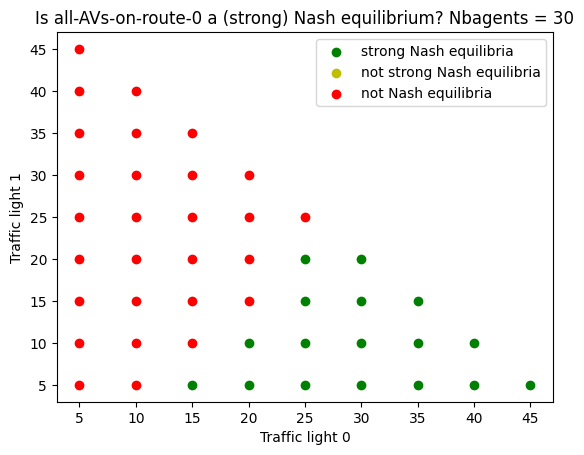

In [ ]:
# Verifying, among all sets of parameters already run, under which sets of static traffic light parameters
# having all AVs on route 0 is a Nash equilibrium, and eventually a strong Nash equilibrium.

snash_x, snash_y = [], []
nash_x, nash_y = [], []
notnash_x, notnash_y = [], []

nbagents = 30 # number of human + AV agents in the network
tl_y = 5 # length of each yellow light phase

for tl_0 in range(5,50,5):
    for tl_1 in range(5,50,5):
        filename = "reward_df_%s_%s_%s_%sagents.csv"%(tl_0, tl_1, tl_y, nbagents)
        try:
            tab_reward = build_rewardtable(filename)
            if nash_equilibrium(id_to_strategy(0)):
                if strong_nash_equilibrium(id_to_strategy(0)):
                    snash_x.append(tl_0)
                    snash_y.append(tl_1)
                else:
                    nash_x.append(tl_0)
                    nash_y.append(tl_1)
            else:
                notnash_x.append(tl_0)
                notnash_y.append(tl_1)
        except:
            # Running a simulation takes way more time than using reward tables that have already been calculated.
            x=0

plt.scatter(snash_x, snash_y, color="g", label="strong Nash equilibria")
plt.scatter(nash_x, nash_y, color="y", label="not strong Nash equilibria")
plt.scatter(notnash_x, notnash_y, color="r", label="not Nash equilibria")
plt.xlabel("Traffic light 0")
plt.ylabel("Traffic light 1")
plt.legend()
plt.title("Is all-AVs-on-route-0 a (strong) Nash equilibrium? Nbagents = %s"%(nbagents))
plt.show()

In [6]:
## How to check whether a custom dynamic trafficlight system is a NE and a SNE

tl_0_list = [i for i in range(45,5,-1)]
for tl_0 in tl_0_list:
    print("tl_0 = ",tl_0)
    tl_list = [(tl_0,50-tl_0,5,23) if nb_1 < 5 else (5,45,5,23) for nb_1 in range(11)]

    custom_df(tl_list)
    tab_reward = build_rewardtable("reward_df_custom.csv")
    print(nash_equilibrium(id_to_strategy(0)))
    print(strong_nash_equilibrium(id_to_strategy(0)))


tl_0 =  45
True
True
tl_0 =  44
True
True
tl_0 =  43
True
True
tl_0 =  42
True
True
tl_0 =  41
True
True
tl_0 =  40
True
True
tl_0 =  39
Reward table for tl_0 = 39, tl_1 = 11, tl_y = 5 and 23 agents was not found. Running...
['<?xml version="1.0" encoding="UTF-8"?>\n', '\n', '<!-- generated on 2025-04-16 16:19:46 by Eclipse SUMO netedit Version 1.22.0\n', '<neteditConfiguration xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance" xsi:noNamespaceSchemaLocation="http://sumo.dlr.de/xsd/neteditConfiguration.xsd">\n', '\n', '    <input>\n', '        <sumo-net-file value="C:\\Users\\Utilisateur\\Desktop\\projectrouterl\\venv\\Lib\\site-packages\\routerl\\networks\\two_route_trafficlight\\two_route_trafficlight.net.xml"/>\n', '    </input>\n', '\n', '    <output>\n', '        <output-file value="C:\\Users\\Utilisateur\\Desktop\\projectrouterl\\venv\\Lib\\site-packages\\routerl\\networks\\two_route_trafficlight\\two_route_trafficlight.net.xml"/>\n', '    </output>\n', '\n', '    <processing>\

(2,38) below threshold, (1,39) above threshold
(3,37) below threshold, (1,39) above threshold
(3,37) below threshold, (2,38) above threshold
(4,36) below threshold, (1,39) above threshold
(4,36) below threshold, (2,38) above threshold
(4,36) below threshold, (3,37) above threshold
(5,35) below threshold, (1,39) above threshold
(5,35) below threshold, (2,38) above threshold
(5,35) below threshold, (3,37) above threshold
(5,35) below threshold, (4,36) above threshold
(6,34) below threshold, (1,39) above threshold
(6,34) below threshold, (2,38) above threshold
(6,34) below threshold, (3,37) above threshold
(6,34) below threshold, (4,36) above threshold
(6,34) below threshold, (5,35) above threshold
(7,33) below threshold, (1,39) above threshold
(7,33) below threshold, (2,38) above threshold
(7,33) below threshold, (3,37) above threshold
(7,33) below threshold, (4,36) above threshold
(7,33) below threshold, (5,35) above threshold
(7,33) below threshold, (6,34) above threshold
(8,32) below 

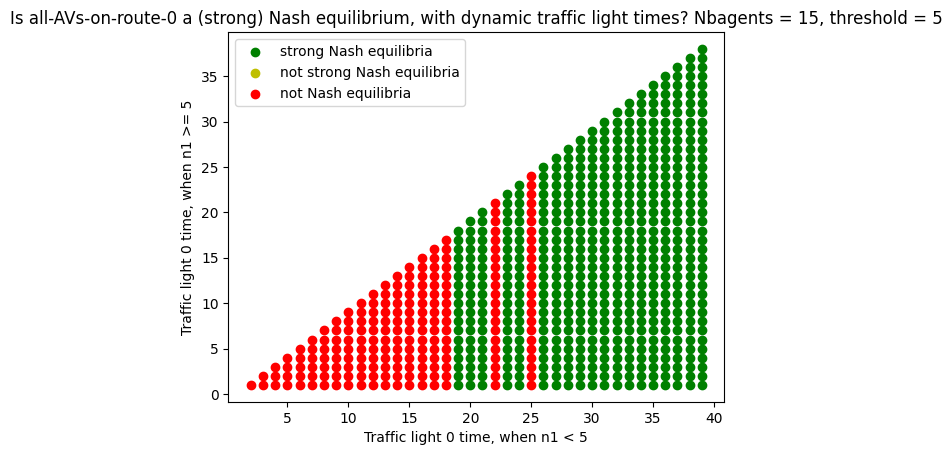

In [ ]:
# Checking under which parameters of a dynamic-traffic-light network, having all AVs on route 0 is a (strong) Nash equilibrium.
# Said parameters are the traffic light durations with few AVs on route 1, and durations with more AVs on route 1.
# 'threshold' is the number of AVs on route 1 necessary to switch between these two modes.

snash_x, snash_y = [], []
nash_x, nash_y = [], []
notnash_x, notnash_y = [], []

nbagents = 15 # number of human + AV agents in the network
threshold = 5 # number of AVs on route 1 beyond which the traffic lights adapt
tl_y = 5 # length of each yellow light phase
cycle_length = 50 # total length of the traffic light cycle

for tl_0_below_threshold in range(1,40):
    for tl_0_above_threshold in range(1,tl_0_below_threshold):

        tl_1_below_threshold = cycle_length - 2*tl_y - tl_0_below_threshold
        tl_1_above_threshold = cycle_length - 2*tl_y - tl_0_above_threshold
        print("(%s,%s) below threshold, (%s,%s) above threshold"%(tl_0_below_threshold,tl_1_below_threshold,tl_0_above_threshold,tl_1_above_threshold))

        tl_list = [(tl_0_below_threshold,tl_1_below_threshold,tl_y,nbagents) if nb_1 < threshold else (tl_0_above_threshold,tl_1_above_threshold,tl_y,nbagents) for nb_1 in range(11)]
        
        custom_df(tl_list)
        tab_reward = build_rewardtable("reward_df_custom.csv")
        if nash_equilibrium(id_to_strategy(0)):
            if strong_nash_equilibrium(id_to_strategy(0)):
                snash_x.append(tl_0_below_threshold)
                snash_y.append(tl_0_above_threshold)
            else:
                nash_x.append(tl_0_below_threshold)
                nash_y.append(tl_0_above_threshold)
        else:
            notnash_x.append(tl_0_below_threshold)
            notnash_y.append(tl_0_above_threshold)

plt.scatter(snash_x, snash_y, color="g", label="strong Nash equilibria")
plt.scatter(nash_x, nash_y, color="y", label="not strong Nash equilibria")
plt.scatter(notnash_x, notnash_y, color="r", label="not Nash equilibria")
plt.xlabel("Traffic light 0 time, when n1 < %s"%(threshold))
plt.ylabel("Traffic light 0 time, when n1 >= %s"%(threshold))
plt.legend()
plt.title("Is all-AVs-on-route-0 a (strong) Nash equilibrium, with dynamic traffic light times? Nbagents = %s, threshold = %s"%(nbagents,threshold))
plt.show()

In [ ]:
nbagents = 15 # number of human + AV agents in the network
threshold = 2 # number of AVs on route 1 beyond which the traffic lights adapt
tl_y = 5 # length of each yellow light phase
cycle_length = 50 # total length of the traffic light cycle

list_t0s = [(20,10)]
for tl_0_below_threshold,tl_0_above_threshold in list_t0s:
    tl_1_below_threshold = cycle_length - 2*tl_y - tl_0_below_threshold
    tl_1_above_threshold = cycle_length - 2*tl_y - tl_0_above_threshold
    print("(%s,%s) below threshold, (%s,%s) above threshold"%(tl_0_below_threshold,tl_1_below_threshold,tl_0_above_threshold,tl_1_above_threshold))

    tl_list = [(tl_0_below_threshold,tl_1_below_threshold,tl_y,nb_agents) if nb_1 < threshold else (tl_0_above_threshold,tl_1_above_threshold,tl_y,nb_agents) for nb_1 in range(11)]
    custom_df(tl_list)
    tab_reward = build_rewardtable("reward_df_custom.csv")

    print(nash_equilibrium(id_to_strategy(0)),strong_nash_equilibrium(id_to_strategy(0)))

(20,20) below threshold, (15,25) above threshold
[1, 6]
[1, 5]
True False
(24,16) below threshold, (15,25) above threshold
[1, 5]
True False


In [29]:
def plot_deviation(club):
    s = coalition_to_strategy(club)
    print("#######################\nClub is %s.\tList of possible deviations:"%(club))
    print("Nash equilibrium: %s, strong equilibrium: %s"%(nash_equilibrium(s),strong_nash_equilibrium(s)))
    p = s_to_reward(s)
    nash_dev = nash_deviation(s)
    y = [-t for t in p]
    yplusdev = [[y[i],y[i] - nash_dev[i]] for i in range(10)]
    return y,yplusdev

In [ ]:
threshold = 2
nb_agents = 15
tl_y = 5
cycle_length = 50

list_t0s = [(20,15),(24,15)]
les_x = [i for i in range(10)]

for tl_0_below_threshold,tl_0_above_threshold in list_t0s:
    fig, ax = plt.subplots()

    ## Building reward table
    tl_1_below_threshold = cycle_length - 2*tl_y  - tl_0_below_threshold
    tl_1_above_threshold = cycle_length - 2*tl_y  - tl_0_above_threshold
    # print("(%s,%s) below threshold, (%s,%s) above threshold"%(tl_0_below_threshold,tl_1_below_threshold,tl_0_above_threshold,tl_1_above_threshold))
    tl_list = [(tl_0_below_threshold,tl_1_below_threshold,tl_y,nb_agents) if nb_1 < threshold else (tl_0_above_threshold,tl_1_above_threshold,tl_y,nb_agents) for nb_1 in range(11)]
    custom_df(tl_list)
    tab_reward = build_rewardtable("reward_df_custom.csv")
    
    
    ## Calculating deviations from the initial situation
    s_beforedeviation = id_to_strategy(0)
    print("#######################\nInitial situation: everyone on route 0.\tList of possible deviations:")
    print("Nash equilibrium: %s, strong equilibrium: %s"%(nash_equilibrium(s_beforedeviation),strong_nash_equilibrium_TU(s_beforedeviation)))

    p_beforedeviation = s_to_reward(s_beforedeviation)
    nash_dev = nash_deviation(s_beforedeviation)
    les_y = [-p for p in p_beforedeviation]
    ax.scatter(les_x,les_y,color='b',label="Travel time before deviation")
    les_yplusdev = [[les_y[i],les_y[i] - nash_dev[i]] for i in range(10)]
    for i in range(10):
        ax.plot([i,i],les_yplusdev[i],color='b',alpha=0.5)

    ## Calculating deviations from the situation after [5,9] deviates
    les_y,les_yplusdev = plot_deviation([4,9])
    ax.scatter(les_x,les_y,color='r',label="Travel time after deviation")
    for i in range(10):
        ax.plot([i,i],les_yplusdev[i],color='r',alpha=0.5)

    ## Calculating deviations from the situation after 4 joins the club
    les_y,les_yplusdev = plot_deviation([4,8,9])
    ax.scatter(les_x,les_y,color='g',label="Travel time after 2nd deviation")
    for i in range(10):
        ax.plot([i,i],les_yplusdev[i],color='g',alpha=0.5)

    ## Filling the legend, labels, etc.
    handles, labels = ax.get_legend_handles_labels()
    blue_line = lines.Line2D([], [], color='b')
    red_line = lines.Line2D([], [], color='r')
    green_line = lines.Line2D([], [], color='g')
    handles.append(blue_line)
    labels.append('Gain from deviating alone')
    handles.append(red_line)
    labels.append('Gain from joining/leaving club')
    handles.append(green_line)
    labels.append('Gain from joining/leaving club')
    ax.legend(handles,labels)
    ax.set_xlabel("Agents")
    ax.set_ylabel("Travel time")

    plt.title("(%s,%s) below threshold, (%s,%s) above threshold, threshold =  %s"%(tl_0_below_threshold,tl_1_below_threshold,tl_0_above_threshold,tl_1_above_threshold,threshold))
    plt.show()

#######################
Initial situation: everyone on route 0.	List of possible deviations:
[5, 6]
[1, 6]
[1, 5]
[1, 5, 6]
Nash equilibrium: True, strong equilibrium: False
#######################
Club is [5, 6].	List of possible deviations:
[1]
Nash equilibrium: False, strong equilibrium: False
#######################
Club is [1, 5, 6].	List of possible deviations:
Nash equilibrium: True, strong equilibrium: True


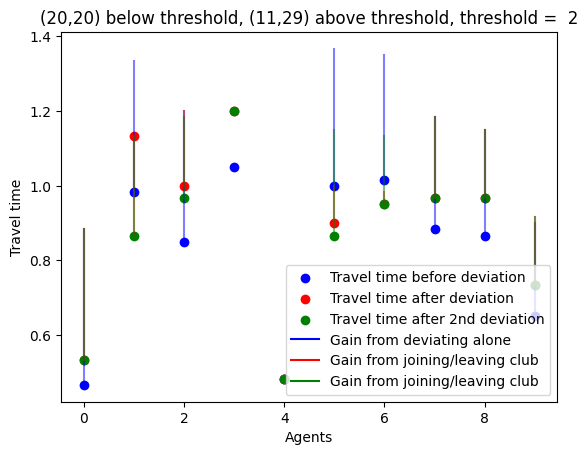

#######################
Initial situation: everyone on route 0.	List of possible deviations:
[5, 6]
[1, 6]
[1, 5]
[1, 5, 6]
Nash equilibrium: True, strong equilibrium: False
#######################
Club is [5, 6].	List of possible deviations:
[1]
[1, 4]
Nash equilibrium: False, strong equilibrium: False
#######################
Club is [1, 5, 6].	List of possible deviations:
Nash equilibrium: True, strong equilibrium: True


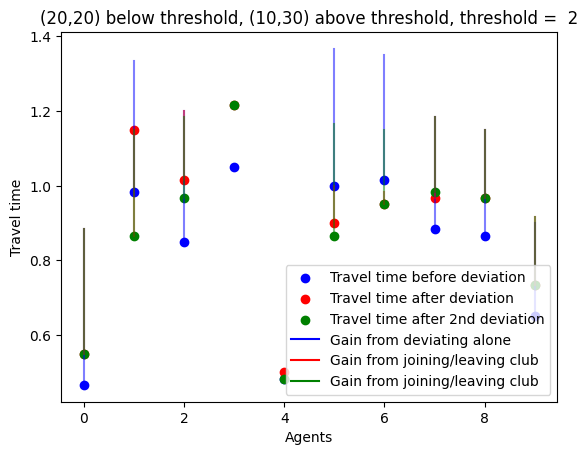

#######################
Initial situation: everyone on route 0.	List of possible deviations:
[5, 7]
[5, 6]
[5, 6, 7]
[1, 6]
[1, 5]
[1, 5, 7]
[1, 5, 6]
[1, 5, 6, 7]
Nash equilibrium: True, strong equilibrium: False
#######################
Club is [5, 6].	List of possible deviations:
[9]
[7]
[7, 9]
[4, 9]
[3]
[3, 9]
[3, 7]
[3, 7, 9]
[3, 4]
[3, 4, 9]
[1]
[1, 9]
[1, 7]
[1, 7, 9]
[1, 4]
[1, 4, 9]
[1, 3]
[1, 3, 9]
[1, 3, 4]
[1, 3, 4, 9]
[0]
[0, 9]
[0, 7]
[0, 7, 9]
[0, 4]
[0, 4, 9]
[0, 3]
[0, 3, 9]
[0, 3, 4]
[0, 3, 4, 9]
[0, 1]
[0, 1, 9]
[0, 1, 4]
[0, 1, 4, 9]
[0, 1, 3]
[0, 1, 3, 9]
[0, 1, 3, 4]
[0, 1, 3, 4, 9]
Nash equilibrium: False, strong equilibrium: False
#######################
Club is [1, 5, 6].	List of possible deviations:
[7]
[0]
[0, 4]
Nash equilibrium: False, strong equilibrium: False


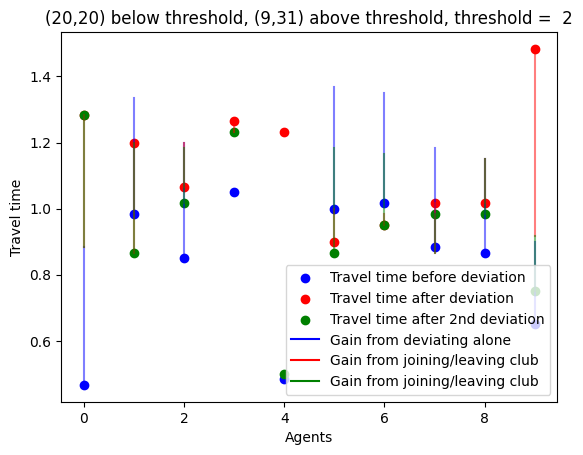

In [ ]:
nbagents = 15 # number of human + AV agents in the network
threshold = 2 # number of AVs on route 1 beyond which the traffic lights adapt
tl_y = 5 # length of each yellow light phase
cycle_length = 50 # total length of the traffic light cycle

list_t0s = [(20,11),(20,10),(20,9)]
les_x = [i for i in range(10)]

for tl_0_below_threshold,tl_0_above_threshold in list_t0s:
    fig, ax = plt.subplots()

    ## Building reward table
    tl_1_below_threshold = cycle_length - 2*tl_y  - tl_0_below_threshold
    tl_1_above_threshold = cycle_length - 2*tl_y  - tl_0_above_threshold
    # print("(%s,%s) below threshold, (%s,%s) above threshold"%(tl_0_below_threshold,tl_1_below_threshold,tl_0_above_threshold,tl_1_above_threshold))
    tl_list = [(tl_0_below_threshold,tl_1_below_threshold,tl_y,nb_agents) if nb_1 < threshold else (tl_0_above_threshold,tl_1_above_threshold,tl_y,nb_agents) for nb_1 in range(11)]
    custom_df(tl_list)
    tab_reward = build_rewardtable("reward_df_custom.csv")
    
    ## Calculating deviations from the initial situation
    s_beforedeviation = id_to_strategy(0)
    print("#######################\nInitial situation: everyone on route 0.\tList of possible deviations:")
    print("Nash equilibrium: %s, strong equilibrium: %s"%(nash_equilibrium(s_beforedeviation),strong_nash_equilibrium(s_beforedeviation)))

    p_beforedeviation = s_to_reward(s_beforedeviation)
    nash_dev = nash_deviation(s_beforedeviation)
    les_y = [-p for p in p_beforedeviation]
    ax.scatter(les_x,les_y,color='b',label="Travel time before deviation")
    les_yplusdev = [[les_y[i],les_y[i] - nash_dev[i]] for i in range(10)]
    for i in range(10):
        ax.plot([i,i],les_yplusdev[i],color='b',alpha=0.5)

    ## Calculating deviations from the situation after [5,9] deviates
    les_y,les_yplusdev = plot_deviation([5,6])
    ax.scatter(les_x,les_y,color='r',label="Travel time after deviation")
    for i in range(10):
        ax.plot([i,i],les_yplusdev[i],color='r',alpha=0.5)

    ## Calculating deviations from the situation after 4 joins the club
    les_y,les_yplusdev = plot_deviation([1,5,6])
    ax.scatter(les_x,les_y,color='g',label="Travel time after 2nd deviation")
    for i in range(10):
        ax.plot([i,i],les_yplusdev[i],color='g',alpha=0.5)

    ## Filling the legend, labels, etc.
    handles, labels = ax.get_legend_handles_labels()
    blue_line = lines.Line2D([], [], color='b')
    red_line = lines.Line2D([], [], color='r')
    green_line = lines.Line2D([], [], color='g')
    handles.append(blue_line)
    labels.append('Gain from deviating alone')
    handles.append(red_line)
    labels.append('Gain from joining/leaving club')
    handles.append(green_line)
    labels.append('Gain from joining/leaving club')
    ax.legend(handles,labels)
    ax.set_xlabel("Agents")
    ax.set_ylabel("Travel time")

    plt.title("(%s,%s) below threshold, (%s,%s) above threshold, threshold =  %s"%(tl_0_below_threshold,tl_1_below_threshold,tl_0_above_threshold,tl_1_above_threshold,threshold))
    plt.show()

## Making sense of payoff matrices

(i had no better idea for the name of this section.)

In [32]:
def travel_times(id):
    s = id_to_strategy(id)
    t0 = 0
    t1 = 0
    n0 = 0
    n1 = 0
    les_t = tab_reward[:,id]
    for i in range(10):
        if s[i] == 0:
            n0 += 1
            t0 += les_t[i]
        else:
            n1 += 1
            t1 += les_t[i]
    if n0 > 0:
        t0 = t0/n0
    if n1 > 0:
        t1 = t1/n1
    return n0, n1, -t0, -t1

[0]
[0, 4]
[0]
[0, 4]
[3, 4]
[0]
[0, 4]
[0, 3, 4]
[0]


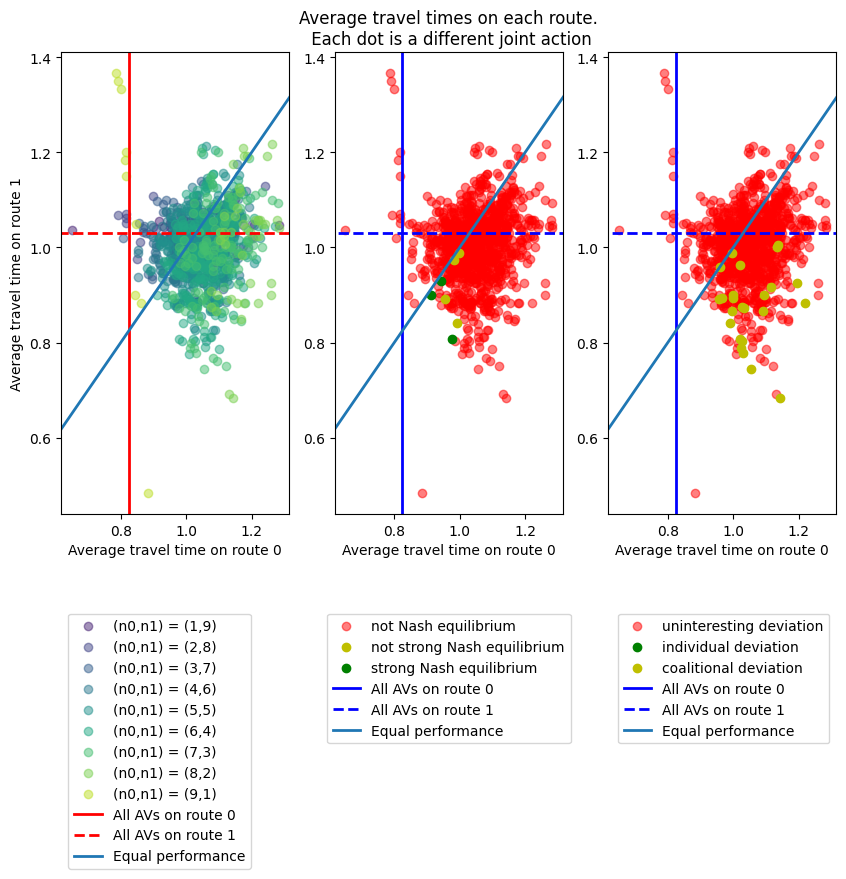

In [ ]:
# set parameters
nbagents = 15 # number of human + AV agents in the network
threshold = 2 # number of AVs on route 1 beyond which the traffic lights adapt
tl_y = 5 # length of each yellow light phase
cycle_length = 50 # total length of the traffic light cycle

# define dynamic traffic light system
tl_0_below_threshold = 20
tl_0_above_threshold = 9
tl_1_below_threshold = cycle_length - 2*tl_y  - tl_0_below_threshold
tl_1_above_threshold = cycle_length - 2*tl_y  - tl_0_above_threshold

# build payoff matrix
tl_list = [(tl_0_below_threshold,tl_1_below_threshold,tl_y,nb_agents) if nb_1 < threshold else (tl_0_above_threshold,tl_1_above_threshold,tl_y,nb_agents) for nb_1 in range(11)]
custom_df(tl_list)
tab_reward = build_rewardtable("reward_df_custom.csv")


## Compute Nash equilibria and deviations

les_t0 = [[] for n0 in range(11)]
les_t1 = [[] for n0 in range(11)]

snash_x, snash_y = [], []
nash_x, nash_y = [], []
notnash_x, notnash_y = [], []

dev_x, dev_y = [], []
sdev_x, sdev_y = [], []
notdev_x, notdev_y = [], []

rew = id_to_reward(0)
list_c = []

for id in range(1024):
    n0,n1,t0,t1 = travel_times(id)
    les_t0[n0].append(t0)
    les_t1[n0].append(t1)

    if n0*n1 > 0: # we remove the dots (n0,n1) = (0,10) and (n0,n1) = (10,0)
        if nash_equilibrium(id_to_strategy(id)):
            if strong_nash_equilibrium(id_to_strategy(id)):
                snash_x.append(t0)
                snash_y.append(t1)
            else:
                nash_x.append(t0)
                nash_y.append(t1)
        else:
            notnash_x.append(t0)
            notnash_y.append(t1)
    
        neigh_s = id_to_strategy(id)
        coalition = strategy_to_coalition(neigh_s)
        alt = s_to_reward(neigh_s)
        gain = 0
        for i in coalition:
            gain += alt[i] - rew[i]
        if gain > 0:
            if n1 == 1:
                dev_x.append(t0)
                dev_y.append(t1)
            else:
                sdev_x.append(t0)
                sdev_y.append(t1)
        else:
            notdev_x.append(t0)
            notdev_y.append(t1)

## Drawing the first plot (colors depend on the flow on each route)

fig = plt.figure()
fig.set_size_inches(10, 6)
ax = fig.add_subplot(1,3,1)

for n0 in range(1,10):
    ax.scatter(les_t0[n0],les_t1[n0],label="(n0,n1) = (%s,%s)"%(n0,10-n0),alpha = 0.5,color = viridis(n0/10))

ax.set_xlabel("Average travel time on route 0")
ax.set_ylabel("Average travel time on route 1")

ax.add_artist(lines.Line2D([les_t0[10],les_t0[10]], [0,2], linewidth=2, color = "r", label="All AVs on route 0"))
ax.add_artist(lines.Line2D([0,2],[les_t1[0],les_t1[0]], linewidth=2,linestyle="--", color = "r", label="All AVs on route 1"))
ax.add_artist(lines.Line2D([0,2], [0,2], linewidth=2, label="Equal performance"))

leg = plt.legend( loc = 'upper left')

plt.draw() # Draw the figure so you can find the positon of the legend. 

# Get the bounding box of the original legend
bb = leg.get_bbox_to_anchor().transformed(ax.transAxes.inverted()) 

# Change to location of the legend. 
Offset = 1.2
bb.y0 -= Offset
bb.y1 -= Offset
leg.set_bbox_to_anchor(bb, transform = ax.transAxes)

## Drawing the second plot (colors depend on the equilibrium status)

ax2 = fig.add_subplot(1,3,2)

ax2.scatter(notnash_x,notnash_y,label="not Nash equilibrium",alpha = 0.5,color = 'r')
ax2.scatter(nash_x,nash_y,label="not strong Nash equilibrium",alpha = 1,color = 'y')
ax2.scatter(snash_x,snash_y,label="strong Nash equilibrium",alpha = 1,color = 'g')

ax2.set_xlabel("Average travel time on route 0")

ax2.add_artist(lines.Line2D([les_t0[10],les_t0[10]], [0,2], linewidth=2, color = "b", label="All AVs on route 0"))
ax2.add_artist(lines.Line2D([0,2],[les_t1[0],les_t1[0]], linewidth=2,linestyle="--", color = "b", label="All AVs on route 1"))
ax2.add_artist(lines.Line2D([0,2], [0,2], linewidth=2, label="Equal performance"))

leg = plt.legend( loc = 'upper center')

ax2.set_title("Average travel times on each route.\n Each dot is a different joint action")
plt.draw() # Draw the figure so you can find the positon of the legend. 

# Get the bounding box of the original legend
bb = leg.get_bbox_to_anchor().transformed(ax.transAxes.inverted()) 

# Change to location of the legend.
bb.y0 -= Offset
bb.y1 -= Offset
leg.set_bbox_to_anchor(bb, transform = ax.transAxes)

## Drawing the third plot (colors depend on how interesting the deviation is)

ax3 = fig.add_subplot(1,3,3)

ax3.scatter(notdev_x,notdev_y,label="uninteresting deviation",alpha = 0.5,color = 'r')
ax3.scatter(dev_x,dev_y,label="individual deviation",alpha = 1,color = 'g')
ax3.scatter(sdev_x,sdev_y,label="coalitional deviation",alpha = 1,color = 'y')

ax3.set_xlabel("Average travel time on route 0")

ax3.add_artist(lines.Line2D([les_t0[10],les_t0[10]], [0,2], linewidth=2, color = "b", label="All AVs on route 0"))
ax3.add_artist(lines.Line2D([0,2],[les_t1[0],les_t1[0]], linewidth=2,linestyle="--", color = "b", label="All AVs on route 1"))
ax3.add_artist(lines.Line2D([0,2], [0,2], linewidth=2, label="Equal performance"))

leg = plt.legend( loc = 'upper right')

plt.draw() # Draw the figure so you can find the positon of the legend. 

# Get the bounding box of the original legend
bb = leg.get_bbox_to_anchor().transformed(ax.transAxes.inverted()) 

# Change to location of the legend.
bb.y0 -= Offset
bb.y1 -= Offset
leg.set_bbox_to_anchor(bb, transform = ax.transAxes)

## Update the plot
plt.show()